<a href="https://colab.research.google.com/github/Atharv-Chopade/Machine_Learning/blob/main/KNN_BreastCancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data , columns = data.feature_names)
df['target'] = data.target

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df['target'].value_counts()

,count
target,
1,357
0,212


In [ ]:
X = df.drop('target' , axis = 1)
y = df['target']

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [ ]:
X_train , X_test , y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [ ]:
X_scaled_train = scaler.fit_transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors = 5)
model.fit(X_scaled_train , y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_scaled_test)

In [ ]:
from sklearn.metrics import classification_report , accuracy_score
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [ ]:
kvalue = []
accuracies = []
for k in range(1 , 50):
  model = KNeighborsClassifier(n_neighbors = k)
  model.fit(X_scaled_train,y_train)
  y_predi = model.predict(X_scaled_test)
  kvalue.append(k)
  accuracies.append(accuracy_score(y_test , y_predi) )


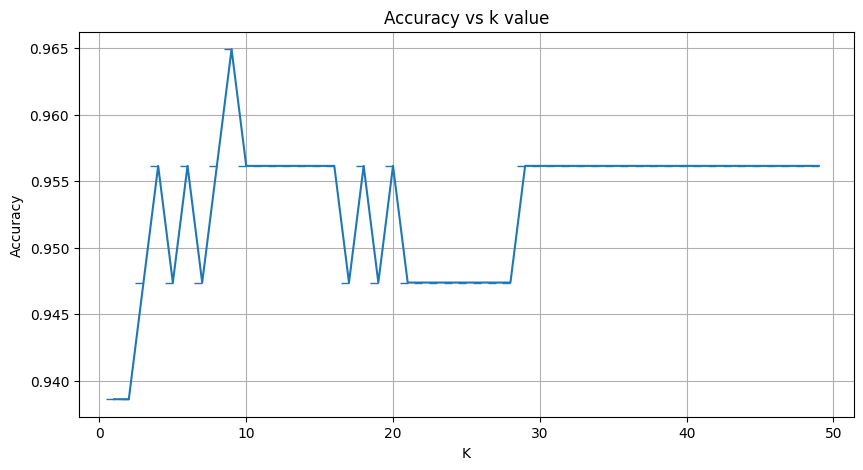

In [ ]:
from matplotlib.lines import lineStyles
plt.figure(figsize= (10 ,  5))
plt.title('Accuracy vs k value')
plt.plot(kvalue , accuracies , marker = 0)
plt.grid(True)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
best_acc = kvalue[accuracies.index(max(accuracies))]
best_acc

9

In [ ]:
from sklearn.model_selection import cross_val_score
model = KNeighborsClassifier(n_neighbors = 5)
scores = cross_val_score(model , X_scaled_train , y_train , cv = 5)
scores

array([0.96703297, 0.95604396, 0.98901099, 0.96703297, 0.92307692])